# Deep Contextual Denoising Autoencoder - Learning an Arbitrary Association
This notebook trains a contextual denoising autoencoder on the MNIST dataset to simulate a neuroscience experiment that investigates the formation of a multisensory association. The goal is to explore how adding a "contextual" input (representing an additional sensory modality) consistently paired with specific visual categories can bias neural representations and behavior. In this setup, the model reconstructs images from noisy inputs and integrates contextual information to capture the association, providing a framework to generate predictions for the real experiment. This version of the notebook is called "deep" because we added an extra fully connected layer between the context and the latent representation.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from scipy.spatial.distance import pdist, squareform
import torch
import os
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torchvision
from torchvision.utils import save_image
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from src.models import *
from src.utils import *
import os

In [3]:
# to prevent crash due to MKL
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# check if cuda is available
cuda_enabled = torch.cuda.is_available()
# print result
print("CUDA is enabled:", cuda_enabled)
# additional information if CUDA is enabled
if cuda_enabled:
    print("CUDA device count:", torch.cuda.device_count())
    print("CUDA current device:", torch.cuda.current_device())
    print("CUDA device name:", torch.cuda.get_device_name(torch.cuda.current_device()))
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
# set dark background for plots
plt.style.use('dark_background')

CUDA is enabled: True
CUDA device count: 1
CUDA current device: 0
CUDA device name: NVIDIA RTX A2000 12GB


### MNIST Data Loading
MNIST images show digits from 0-9 in 28x28 grayscale images. We normalize and center them around 0, which gives a slight performance boost during training. We create both a training set and a test set. This time we will also add noise to the images to be reconstructed during training.

In [4]:
# set batch size
batch_size = 128
# define preprocessing image transformation for MNIST dataset
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
# load MNIST dataset, training set
train_dataset = MNIST(root='./data/MNIST', download=True, train=True, transform=img_transform)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# load MNIST dataset, testing set
test_dataset = MNIST(root='./data/MNIST', download=True, train=False, transform=img_transform)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

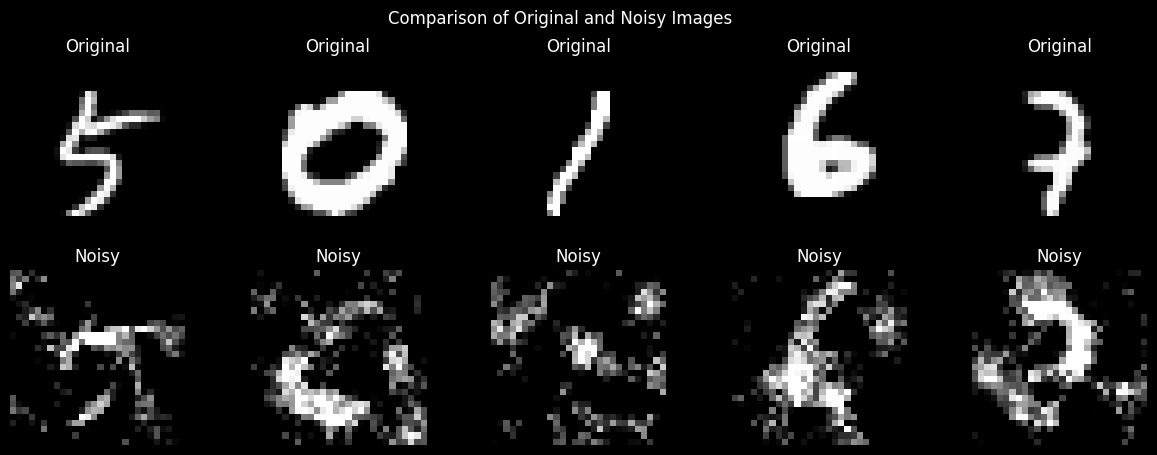

Images batch shape: torch.Size([128, 1, 28, 28])


In [5]:
# set noise level for the context and training data
training_noise_level = 0.5  # noise level of the training data

# select a batch of images from the training data
images, _ = next(iter(train_dataloader))

# generate noisy images using the `add_noise` function with both correlated and uncorrelated noise
noisy_images = add_noise(
    images, 
    noise_level=training_noise_level, 
    correlated=True,  # set to True to apply correlated noise
    uncorrelated=True,  # set to True to apply uncorrelated noise
    kernel_size=11,  # kernel size for the Gaussian filter
    sigma=2.0  # standard deviation of the Gaussian filter
)

# visualize the images to inspect the level of noise corruption that will be used for training
visualize_noisy_images(images, noisy_images, num_images=5)

# print the shape of the images tensor
print("Images batch shape:", images.shape)


In [6]:
# Hyperparameters
learning_rate = 0.001
num_epochs_baseline = 50
num_epochs_association = 100
context_dim = 10  # adjustable context dimensionality
capacity = 16  # model capacity
latent_dims = 32  # latent space dimensionality
target_digit = 3  # digit associated with high-value whisker context
context_signal_level = 1.00  # signal level of the context
context_noise_level = 0.10  # noise level of the context
context_id = 2  # context position in the context vector

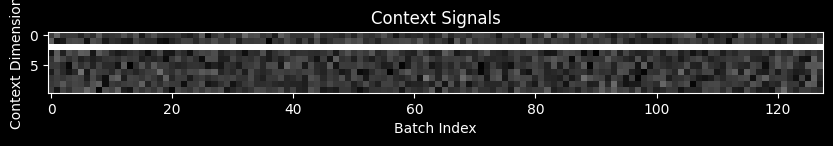

Context batch shape: torch.Size([128, 10])


In [7]:
# generate a batch of context signals
context_batch = generate_context(noisy_images.size(0),
                                 signal_level=context_signal_level,
                                 noise_level=context_noise_level,
                                 category_id=context_id,
                                 context_dim=context_dim,
                                 device=device)

# visualize the context signals as a heatmap
plt.figure(figsize=(10, 5))
plt.imshow(context_batch.T.cpu(), cmap='gray', interpolation='nearest')
plt.title("Context Signals")
plt.ylabel("Context Dimension")
plt.xlabel("Batch Index")
plt.show()

# print the shape of the context tensor
print("Context batch shape:", context_batch.shape)

Baseline Training Phase (Denoising Autoencoder)
Epoch 1/50, Baseline Loss: 0.18742781702770608
Epoch 2/50, Baseline Loss: 0.11811245915922783
Epoch 3/50, Baseline Loss: 0.10451453760552254
Epoch 4/50, Baseline Loss: 0.09733489956428755
Epoch 5/50, Baseline Loss: 0.09316411293518823
Epoch 6/50, Baseline Loss: 0.09026285351466523
Epoch 7/50, Baseline Loss: 0.0881590830650665
Epoch 8/50, Baseline Loss: 0.08636564804292692
Epoch 9/50, Baseline Loss: 0.0853446149972202
Epoch 10/50, Baseline Loss: 0.08427964543292263
Epoch 11/50, Baseline Loss: 0.08345011065700161
Epoch 12/50, Baseline Loss: 0.08286089500956444
Epoch 13/50, Baseline Loss: 0.08201049388980051
Epoch 14/50, Baseline Loss: 0.08149324379750152
Epoch 15/50, Baseline Loss: 0.08112355667962702
Epoch 16/50, Baseline Loss: 0.0807981446290067
Epoch 17/50, Baseline Loss: 0.08012276150778666
Epoch 18/50, Baseline Loss: 0.07993441421403559
Epoch 19/50, Baseline Loss: 0.07930616397402689
Epoch 20/50, Baseline Loss: 0.07894267302268604
Epoc

C:\Users\usr_m_elbousta1\AppData\Local\Temp\ipykernel_32956\1398214742.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  baseline_autoencoder.load_state_dict(torch.load(b

Epoch 1/100, Association Loss: 0.07437215110005092
Epoch 2/100, Association Loss: 0.07415144269400314
Epoch 3/100, Association Loss: 0.07402014050847178
Epoch 4/100, Association Loss: 0.07399893478988838
Epoch 5/100, Association Loss: 0.07420974564768358
Epoch 6/100, Association Loss: 0.07433867365566653
Epoch 7/100, Association Loss: 0.07435636080976234
Epoch 8/100, Association Loss: 0.07432996333916304
Epoch 9/100, Association Loss: 0.0743365155608415
Epoch 10/100, Association Loss: 0.07418410589636516
Epoch 11/100, Association Loss: 0.0740878175316589
Epoch 12/100, Association Loss: 0.07418506546442442
Epoch 13/100, Association Loss: 0.07439790915515122
Epoch 14/100, Association Loss: 0.07435884339405276
Epoch 15/100, Association Loss: 0.07409433142017963
Epoch 16/100, Association Loss: 0.07416017544167891
Epoch 17/100, Association Loss: 0.07414176175271524
Epoch 18/100, Association Loss: 0.0742912064356082
Epoch 19/100, Association Loss: 0.07409758937320729
Epoch 20/100, Associatio

C:\Users\usr_m_elbousta1\AppData\Local\Temp\ipykernel_32956\1398214742.py:140: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  association_autoencoder.load_state_dict(torch.lo

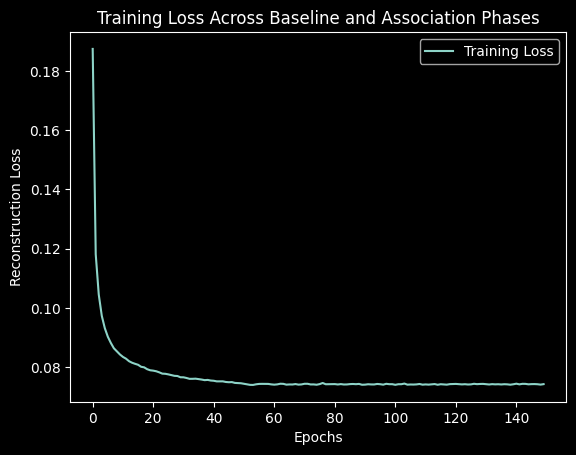

In [8]:
# set retrain flag and define file paths for both models
retrain = False
pretrained_dir = './pretrained'
baseline_model_path = os.path.join(pretrained_dir, 'baseline_deep_autoencoder.pth')
association_model_path = os.path.join(pretrained_dir, 'association_deep_autoencoder.pth')
if not os.path.isdir(pretrained_dir):
    os.makedirs(pretrained_dir)

# instantiate model and define optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = Autoencoder(capacity, latent_dims, context_dim).to(device)

# load models if they exist and retrain is set to False
baseline_trained = os.path.isfile(baseline_model_path)
association_trained = os.path.isfile(association_model_path)

if not retrain and baseline_trained and association_trained:

    # load both models
    baseline_autoencoder = Autoencoder(capacity, latent_dims, context_dim).to(device)
    association_autoencoder = Autoencoder(capacity, latent_dims, context_dim).to(device)
    baseline_autoencoder.load_state_dict(torch.load(baseline_model_path))
    association_autoencoder.load_state_dict(torch.load(association_model_path))
    print("Loaded pretrained baseline and association models.")

else:

    # initialize the optimizer
    optimizer = torch.optim.Adam(autoencoder.parameters(), lr=learning_rate)
    # initialize the training loss list
    train_loss_avg = []

    # baseline training phase
    print("Baseline Training Phase (Denoising Autoencoder)")
    for epoch in range(num_epochs_baseline):
        total_loss = 0
        for image_batch, _ in train_dataloader:
            image_batch = image_batch.to(device)

            # generate context for the batch (default)
            context_batch = generate_context(image_batch.size(0),
                                                   signal_level=None,
                                                   noise_level=context_noise_level,
                                                   category_id=context_id,
                                                   context_dim=context_dim,
                                                   device=device)
            # apply noise to inputs
            noisy_image_batch = add_noise(image_batch, 
                                        noise_level=training_noise_level, 
                                        correlated=True,  # set to True to apply correlated noise
                                        uncorrelated=True,  # set to True to apply uncorrelated noise
                                        kernel_size=11,  # kernel size for the Gaussian filter
                                        sigma=2.0  # standard deviation of the Gaussian filter
                                        )

            # forward pass with noisy input
            reconstructed = autoencoder(noisy_image_batch, context_batch)
            loss = F.mse_loss(reconstructed, image_batch)  

            # backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # calculate the average loss
        avg_loss = total_loss / len(train_dataloader)
        train_loss_avg.append(avg_loss)
        print(f"Epoch {epoch + 1}/{num_epochs_baseline}, Baseline Loss: {avg_loss}")

    # save the baseline model
    torch.save(autoencoder.state_dict(), baseline_model_path)
    print(f"Baseline model saved to {baseline_model_path}")

    # copy the baseline model state to a separate variable for later analysis
    baseline_autoencoder = Autoencoder(capacity, latent_dims, context_dim).to(device)
    baseline_autoencoder.load_state_dict(torch.load(baseline_model_path))

    # freeze all parts of the network except the context layer before association training
    freeze_except_context(autoencoder)

    # update the optimizer to only include the trainable parameters (i.e., the context layer)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, autoencoder.parameters()), lr=learning_rate)

    # association training phase
    print("\nAssociation Training Phase (Denoising Autoencoder with Enhanced Context - Frozen Weights)")
    for epoch in range(num_epochs_association):
        total_loss = 0
        for image_batch, label_batch in train_dataloader:
            image_batch = image_batch.to(device)
            label_batch = label_batch.to(device)
            
            # generate context for the batch (default)
            context_batch = generate_context(image_batch.size(0),
                                                   signal_level=None,
                                                   noise_level=context_noise_level,
                                                   category_id=context_id,
                                                   context_dim=context_dim,
                                                   device=device)
            # generate context for the batch (associative context)
            target_indices = (label_batch == target_digit).nonzero(as_tuple=True)[0]
            if len(target_indices) > 0:
                context_batch[target_indices] = generate_context(len(target_indices),
                                                   signal_level=context_signal_level,
                                                   noise_level=context_noise_level,
                                                   category_id=context_id,
                                                   context_dim=context_dim,
                                                   device=device)

            # apply noise to inputs
            noisy_image_batch = add_noise(image_batch, 
                                        noise_level=training_noise_level, 
                                        correlated=True,  # set to True to apply correlated noise
                                        uncorrelated=True,  # set to True to apply uncorrelated noise
                                        kernel_size=11,  # kernel size for the Gaussian filter
                                        sigma=2.0  # standard deviation of the Gaussian filter
                                        )

            # forward pass with noisy input
            reconstructed = autoencoder(noisy_image_batch, context_batch)
            loss = F.mse_loss(reconstructed, image_batch)

            # backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        # calculate the average loss
        avg_loss = total_loss / len(train_dataloader)
        train_loss_avg.append(avg_loss)
        print(f"Epoch {epoch + 1}/{num_epochs_association}, Association Loss: {avg_loss}")

    # save the association model
    torch.save(autoencoder.state_dict(), association_model_path)
    print(f"Association model saved to {association_model_path}")

    # copy the association model state to a separate variable for later analysis
    association_autoencoder = Autoencoder(capacity, latent_dims, context_dim).to(device)
    association_autoencoder.load_state_dict(torch.load(association_model_path))

    # plot the training curve across both phases
    plt.plot(range(num_epochs_baseline + num_epochs_association), train_loss_avg, label="Training Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Reconstruction Loss")
    plt.legend()
    plt.title("Training Loss Across Baseline and Association Phases")
    plt.show()

Original Images


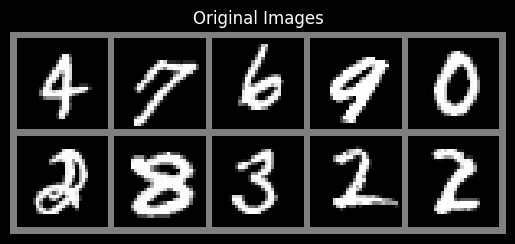

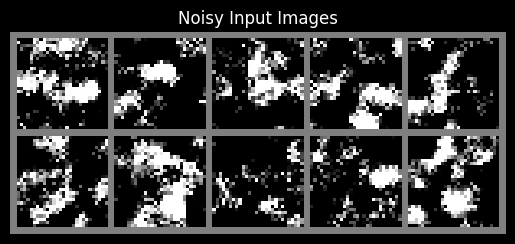

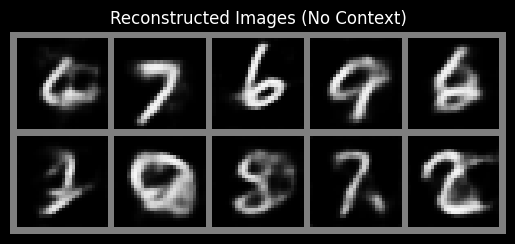

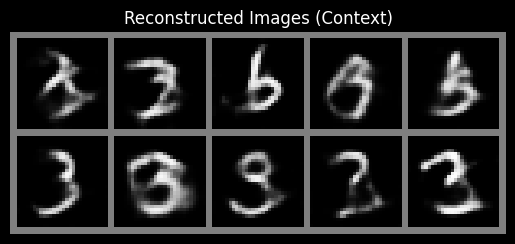

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9999999..0.95353127].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.98679984].


In [9]:
# ensure inline plotting for Jupyter notebooks
%matplotlib inline

# ensure the model is in evaluation mode
association_autoencoder.eval()

# display image grid
def show_image(img, title=""):
    img = img.cpu()
    img = 0.5 * (img + 1)
    img = img.clamp(0, 1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# set the context signal level for the test set
test_context_signal_level = 10.0  # signal level of the context

# load a batch of images from the test set and move to the correct device
images_test, labels_test = next(iter(test_dataloader))
images_test = images_test.to(device)

# generate noisy images using the `add_noise` function
noisy_images_test = add_noise(images_test, noise_level=1.0,
                              correlated=True, uncorrelated=True,
                              kernel_size=11, sigma=2.0)

# generate context vectors
context_test = generate_context(noisy_images_test.size(0), signal_level=test_context_signal_level,
                                noise_level=context_noise_level, category_id=context_id,
                                context_dim=10, device=device)
no_context_test = generate_context(noisy_images_test.size(0), signal_level=None,
                                   noise_level=context_noise_level, category_id=context_id,
                                   context_dim=10, device=device)

# get the reconstructed images
reconstructed_images_context = association_autoencoder(noisy_images_test, context_test).cpu()
reconstructed_images_no_context = association_autoencoder(noisy_images_test, no_context_test).cpu()

# display the original, noisy, and reconstructed images
print("Original Images")
show_image(torchvision.utils.make_grid(images_test[:10], nrow=5), title="Original Images")
show_image(torchvision.utils.make_grid(noisy_images_test[:10].cpu(), nrow=5), title="Noisy Input Images")
show_image(torchvision.utils.make_grid(reconstructed_images_no_context[:10], nrow=5), title="Reconstructed Images (No Context)")
show_image(torchvision.utils.make_grid(reconstructed_images_context[:10], nrow=5), title="Reconstructed Images (Context)")

# ensure the output directory exists
output_dir = "./output"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# function to save images at higher resolution
def save_high_res_image(tensor, filename, nrow=5, figsize=(15, 15)):
    grid_img = torchvision.utils.make_grid(tensor, nrow=nrow, padding=2, scale_each=True)
    plt.figure(figsize=figsize)  # Set figure size for higher resolution
    plt.imshow(grid_img.permute(1, 2, 0).cpu().numpy())  # Convert to (H, W, C) format and move to CPU
    plt.axis('off')
    plt.savefig(filename, bbox_inches='tight', dpi=300)  # Save with higher DPI for better resolution
    plt.close()

# save the images
save_high_res_image(images_test[:10], os.path.join(output_dir, "original_images.png"))
save_high_res_image(noisy_images_test[:10].cpu(), os.path.join(output_dir, "noisy_images.png"))
save_high_res_image(reconstructed_images_no_context[:10], os.path.join(output_dir, "reconstructed_images_no_context.png"))
save_high_res_image(reconstructed_images_context[:10], os.path.join(output_dir, "reconstructed_images_context.png"))

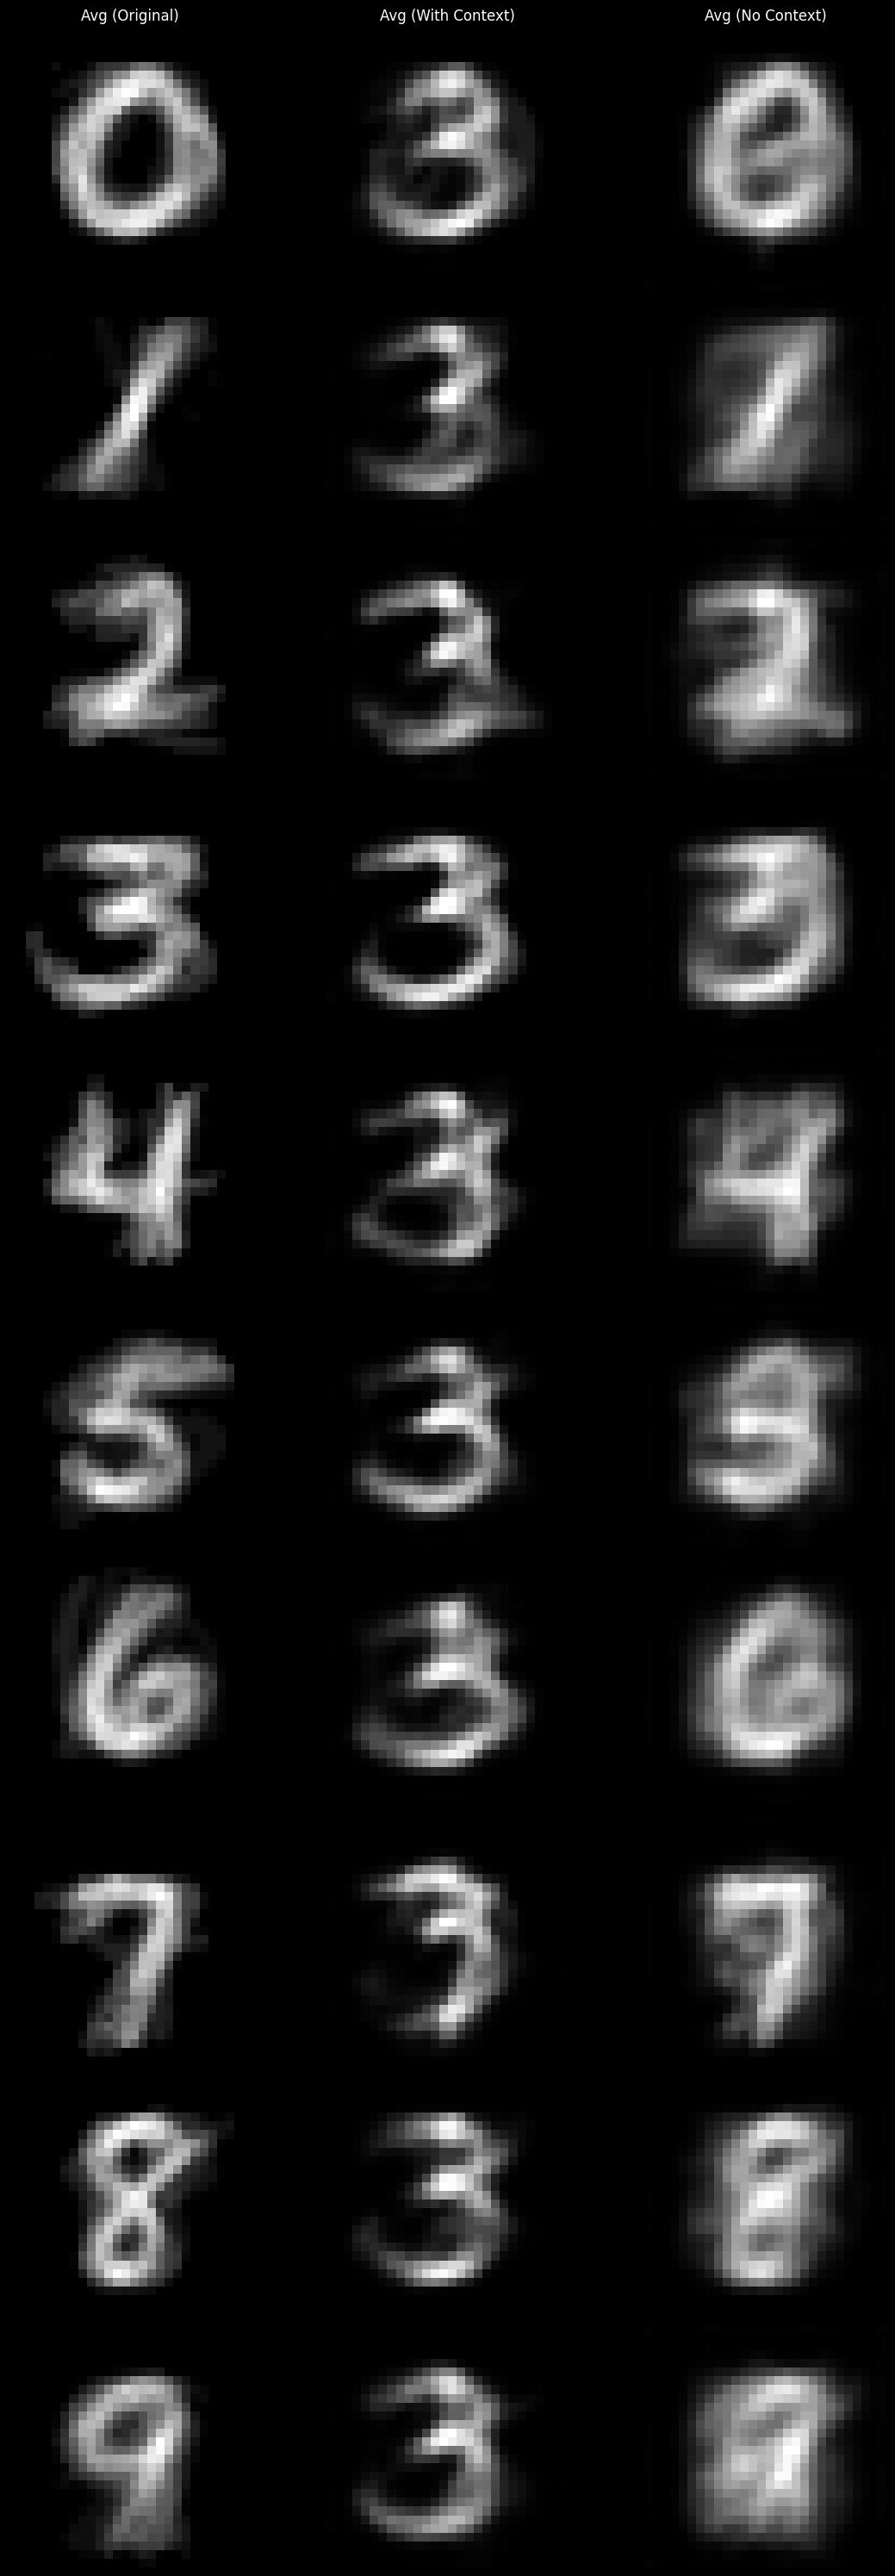

In [10]:
# ensure inline plotting for Jupyter notebooks
%matplotlib inline

# ensure the model is in evaluation mode
association_autoencoder.eval()

# load a batch of images from the test set and move to the correct device
images_test, labels_test = next(iter(test_dataloader))
images_test = images_test.to(device)

# generate noisy images using the `add_noise` function
noisy_images_test = add_noise(images_test, noise_level=1.0, correlated=True, uncorrelated=True, kernel_size=11, sigma=2.0)

# generate context vectors
context_test = generate_context(noisy_images_test.size(0), signal_level=test_context_signal_level, noise_level=context_noise_level, category_id=context_id, context_dim=10, device=device)
no_context_test = generate_context(noisy_images_test.size(0), signal_level=None, noise_level=context_noise_level, category_id=context_id, context_dim=10, device=device)

# get the reconstructed images
reconstructed_images_context = association_autoencoder(noisy_images_test, context_test).cpu()
reconstructed_images_no_context = association_autoencoder(noisy_images_test, no_context_test).cpu()

# function to calculate and visualize average images per category
def plot_average_images(images, labels, reconstructions_with_context, reconstructions_no_context):
    fig, axes_avg = plt.subplots(10, 3, figsize=(12, 30))

    for i in range(10):  # iterate over digit categories
        indices = np.where(labels.cpu().numpy() == i)[0]

        if len(indices) > 0:  # ensure we have samples for this digit
            avg_original = images[indices].mean(dim=0).detach().cpu().numpy()
            avg_with_context = reconstructions_with_context[indices].mean(dim=0).detach().cpu().numpy()
            avg_no_context = reconstructions_no_context[indices].mean(dim=0).detach().cpu().numpy()

            # plot average original image
            axes_avg[i, 0].imshow(avg_original.reshape(28, 28), cmap='gray')
            axes_avg[i, 0].axis('off')
            if i == 0:
                axes_avg[i, 0].set_title('Avg (Original)')

            # plot average image with context
            axes_avg[i, 1].imshow(avg_with_context.reshape(28, 28), cmap='gray')
            axes_avg[i, 1].axis('off')
            if i == 0:
                axes_avg[i, 1].set_title('Avg (With Context)')

            # plot average image without context
            axes_avg[i, 2].imshow(avg_no_context.reshape(28, 28), cmap='gray')
            axes_avg[i, 2].axis('off')
            if i == 0:
                axes_avg[i, 2].set_title('Avg (No Context)')

            axes_avg[i, 0].set_ylabel(f'Digit {i}', fontsize=12)

    plt.tight_layout()
    plt.show()

# visualize average reconstructions for each category
plot_average_images(images_test, labels_test, reconstructed_images_context, reconstructed_images_no_context)


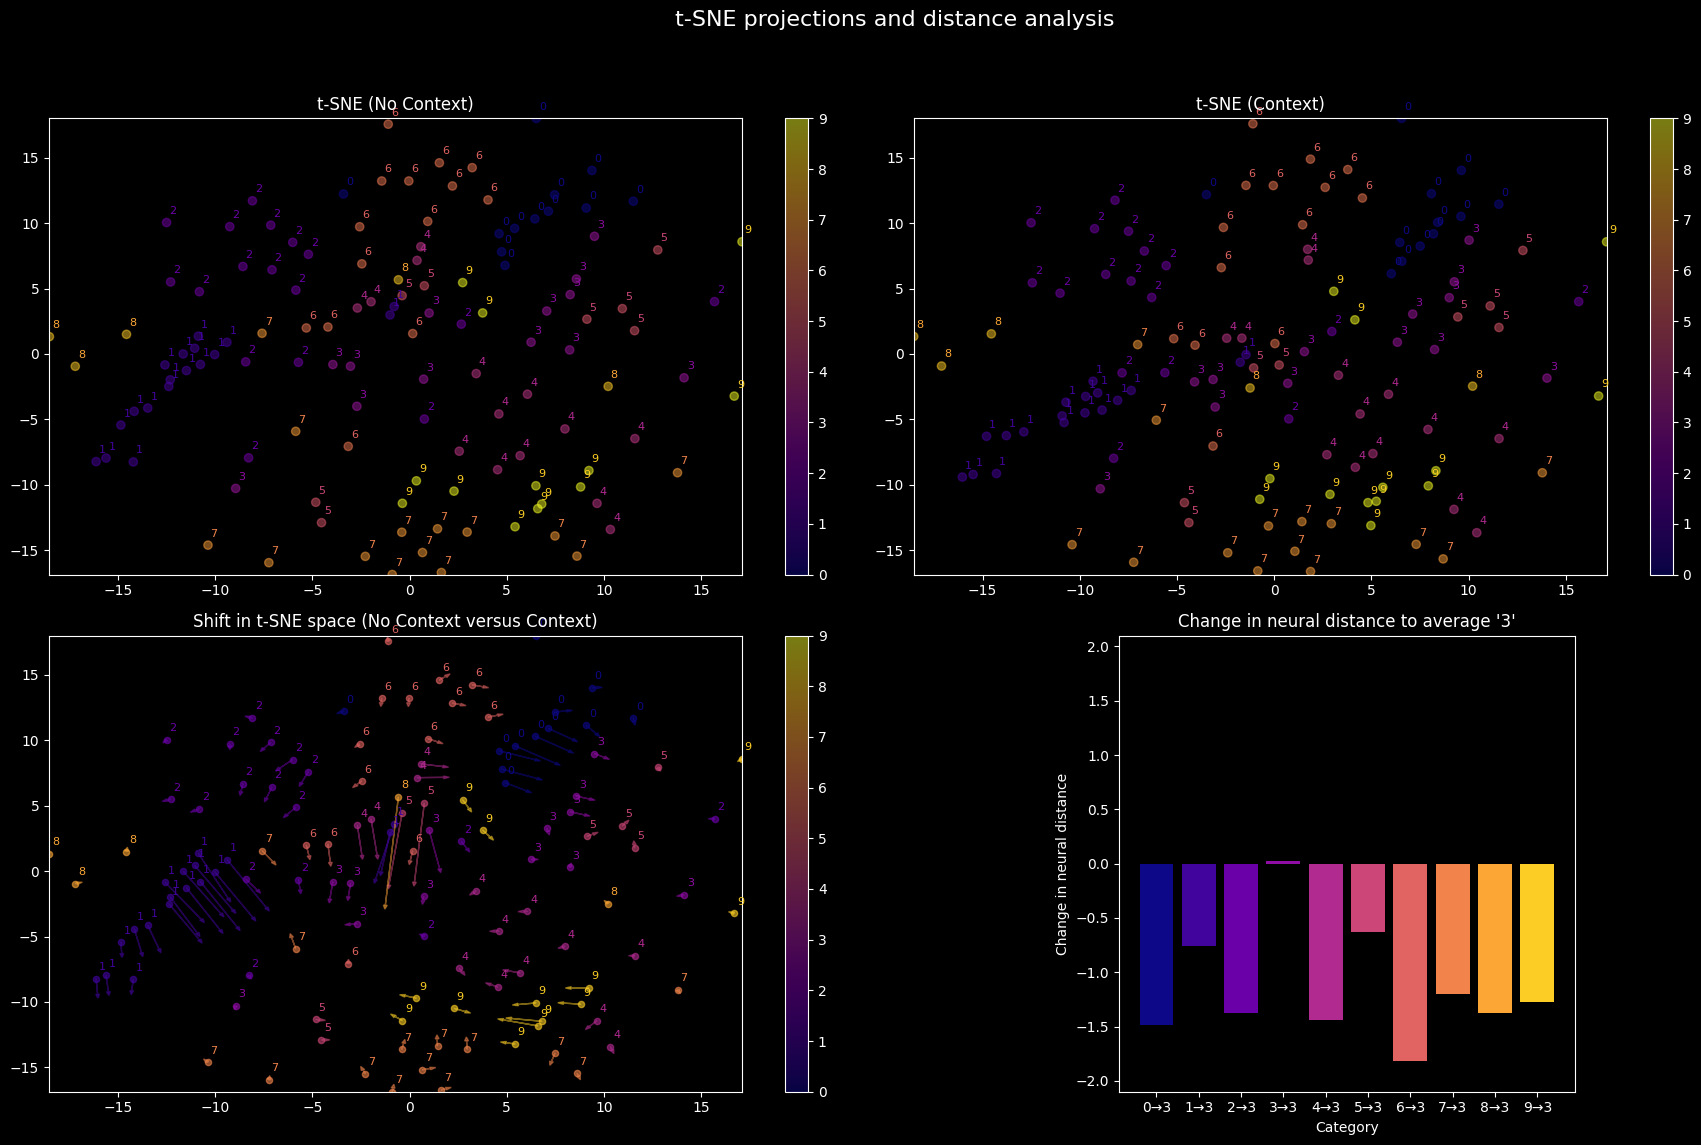

In [11]:
# capture activations from the autoencoder
def capture_activations(model, images, context):
    with torch.no_grad():
        latent = model.encoder(images, context)
        return latent.detach().cpu().numpy()

# ensure the model is in evaluation mode
association_autoencoder.eval()

# load a batch of images from the test set and move to the correct device
images_test, labels_test = next(iter(test_dataloader))
images_test = images_test.to(device)
labels_test = labels_test.cpu().numpy()

# generate noisy images
noisy_images_test = add_noise(images_test, noise_level=training_noise_level, correlated=True, uncorrelated=True, kernel_size=11, sigma=2.0)

# generate context vectors
context_test = generate_context(noisy_images_test.size(0), signal_level=test_context_signal_level, noise_level=context_noise_level, category_id=context_id, context_dim=10, device=device)
no_context_test = generate_context(noisy_images_test.size(0), signal_level=None, noise_level=context_noise_level, category_id=context_id, context_dim=10, device=device)

# capture activations
activations_no_context = capture_activations(association_autoencoder, noisy_images_test, no_context_test)
activations_context = capture_activations(association_autoencoder, noisy_images_test, context_test)

# average activation for "3" with and without context
avg_activation_3_no_context = activations_no_context[labels_test == 3].mean(axis=0)
avg_activation_3_context = activations_context[labels_test == 3].mean(axis=0)
avg_activation_3_avg = (avg_activation_3_no_context + avg_activation_3_context) / 2

# compute change in distance from "3" average activation
distance_diffs = [
    np.linalg.norm(activations_context[labels_test == i] - avg_activation_3_avg, axis=1).mean() -
    np.linalg.norm(activations_no_context[labels_test == i] - avg_activation_3_avg, axis=1).mean()
    for i in range(10)
]

# perform t-SNE on combined activations
combined_activations = np.concatenate([activations_no_context, activations_context], axis=0)
combined_labels = np.concatenate([labels_test, labels_test + 10]) 
tsne = TSNE(n_components=2, random_state=0)
combined_tsne = tsne.fit_transform(combined_activations)

# split the t-SNE results
latent_no_context_tsne = combined_tsne[:len(activations_no_context)]
latent_context_tsne = combined_tsne[len(activations_no_context):]

# set axis limits for synchronization
x_min, x_max = combined_tsne[:, 0].min(), combined_tsne[:, 0].max()
y_min, y_max = combined_tsne[:, 1].min(), combined_tsne[:, 1].max()

# plotting
fig, axs = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("t-SNE projections and distance analysis", fontsize=16)

# t-SNE without context
axs[0, 0].set_title("t-SNE (No Context)")
scatter = axs[0, 0].scatter(latent_no_context_tsne[:, 0], latent_no_context_tsne[:, 1], c=labels_test, cmap='plasma', alpha=0.5)
axs[0, 0].figure.colorbar(scatter, ax=axs[0, 0], ticks=range(10))
for i, (x, y) in enumerate(latent_no_context_tsne):
    axs[0, 0].text(x + 0.5, y + 0.5, str(labels_test[i]), fontsize=8, ha='right', va='bottom', color=plt.cm.plasma(labels_test[i] / 10))
axs[0, 0].set_xlim(x_min, x_max)
axs[0, 0].set_ylim(y_min, y_max)

# t-SNE with context
axs[0, 1].set_title("t-SNE (Context)")
scatter = axs[0, 1].scatter(latent_context_tsne[:, 0], latent_context_tsne[:, 1], c=labels_test, cmap='plasma', alpha=0.5)
axs[0, 1].figure.colorbar(scatter, ax=axs[0, 1], ticks=range(10))
for i, (x, y) in enumerate(latent_context_tsne):
    axs[0, 1].text(x + 0.5, y + 0.5, str(labels_test[i]), fontsize=8, ha='right', va='bottom', color=plt.cm.plasma(labels_test[i] / 10))
axs[0, 1].set_xlim(x_min, x_max)
axs[0, 1].set_ylim(y_min, y_max)

# t-SNE with arrows showing shifts
axs[1, 0].set_title("Shift in t-SNE space (No Context versus Context)")
for i, (x_nc, y_nc) in enumerate(latent_no_context_tsne):
    x_wc, y_wc = latent_context_tsne[i]
    axs[1, 0].arrow(x_nc, y_nc, x_wc - x_nc , y_wc - y_nc, color=plt.cm.plasma(labels_test[i] / 10), head_width=0.2, alpha=0.5)
    axs[1, 0].scatter(x_nc, y_nc, color=plt.cm.plasma(labels_test[i] / 10), s=20, alpha=0.6)
for i, (x, y) in enumerate(latent_no_context_tsne):
    axs[1, 0].text(x + 0.5, y + 0.5, str(labels_test[i]), fontsize=8, ha='right', va='bottom', color=plt.cm.plasma(labels_test[i] / 10))
axs[1, 0].figure.colorbar(scatter, ax=axs[1, 0], ticks=range(10))
axs[1, 0].set_xlim(x_min, x_max)
axs[1, 0].set_ylim(y_min, y_max)

# histogram for distance change
axs[1, 1].bar(range(10), distance_diffs, color=plt.cm.plasma(np.arange(10) / 10))
axs[1, 1].set_xticks(range(10))
axs[1, 1].set_xticklabels([f"{i}→3" for i in range(10)])
axs[1, 1].set_title("Change in neural distance to average '3'")
axs[1, 1].set_xlabel("Category")
axs[1, 1].set_ylabel("Change in neural distance")
axs[1, 1].set_box_aspect(1)
axs[1, 1].set_ylim(-1.1*np.max(np.abs(distance_diffs)) - 0.1, 1.1*np.max(np.abs(distance_diffs)) + 0.1)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

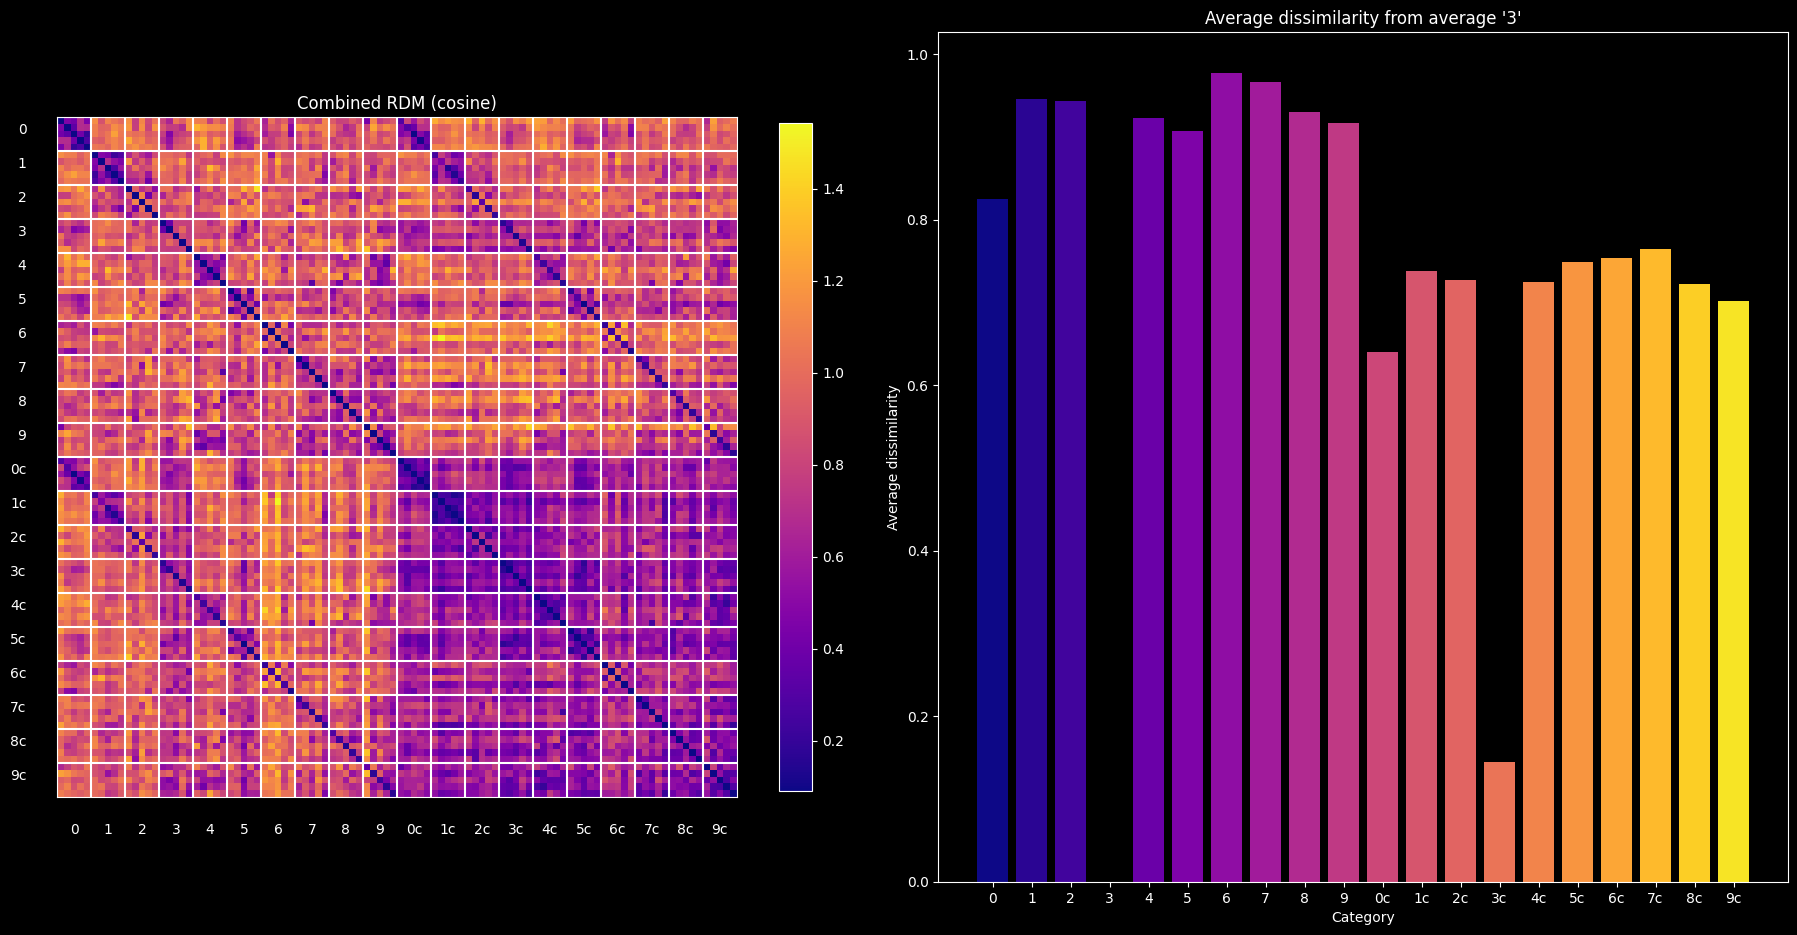

In [12]:
# ensure labels are numpy arrays for indexing
labels_test = labels_test

# RDM analysis with balanced samples per category
samples_per_class = min(len(labels_test[labels_test == i]) for i in range(10))  # Ensure we have enough samples
balanced_indices = np.concatenate([
    np.random.choice(np.where(labels_test == i)[0], samples_per_class, replace=False) for i in range(10)
])

# prepare balanced activations for the RDM
balanced_no_context = activations_no_context[balanced_indices]
balanced_with_context = activations_context[balanced_indices]
balanced_combined_activations = np.concatenate([balanced_no_context, balanced_with_context], axis=0)
balanced_combined_labels = np.concatenate([labels_test[balanced_indices], labels_test[balanced_indices] + 10])

# compute the RDM (Representational Dissimilarity Matrix) using cosine distance
rdm_combined = squareform(pdist(balanced_combined_activations, metric='cosine'))
avg_3_dissimilarities = [
    rdm_combined[balanced_combined_labels == 3, balanced_combined_labels == i].mean()
    for i in range(10)
] + [
    rdm_combined[balanced_combined_labels == 3, balanced_combined_labels == i + 10].mean()
    for i in range(10)
]

# plot the combined RDM
fig, ax = plt.subplots(1, 2, figsize=(18, 10))
ax[0].set_title("Combined RDM (cosine)")
rdm_plot = ax[0].imshow(rdm_combined, cmap='plasma', interpolation='nearest')

# adjust the colorbar size using the 'shrink' parameter
cbar = fig.colorbar(rdm_plot, ax=ax[0], shrink=0.75)  # Shrink to 75% of its original size

# set colormap limits excluding the diagonal
min_val = np.min(np.ma.masked_where(np.eye(len(balanced_combined_labels), dtype=bool), rdm_combined))
max_val = np.max(rdm_combined)
rdm_plot.set_clim(min_val, max_val)

# add separators and labels to the RDM plot
for i in range(20):  # 10 original + 10 context-modified categories
    ax[0].axhline(i * samples_per_class - 0.5, color='white', linewidth=1.5)
    ax[0].axvline(i * samples_per_class - 0.5, color='white', linewidth=1.5)
    label_text = str(i % 10) + ("c" if i >= 10 else "")
    ax[0].text(-5, i * samples_per_class + samples_per_class / 2 - 0.5, label_text, color="white", fontsize=10, ha='right')
    ax[0].text(i * samples_per_class + samples_per_class / 2 - 0.5, len(balanced_combined_labels) + 5, label_text, color="white", fontsize=10, ha='center')
ax[0].set_xticks([])
ax[0].set_yticks([])

# plot the average dissimilarity histogram from "3" (no context)
ax[1].bar(range(20), avg_3_dissimilarities, color=plt.cm.plasma(np.arange(20) / 20))
ax[1].set_xticks(range(20))
ax[1].set_xticklabels([str(i) for i in range(10)] + [f"{i}c" for i in range(10)])
ax[1].set_title("Average dissimilarity from average '3'")
ax[1].set_xlabel("Category")
ax[1].set_ylabel("Average dissimilarity")
ax[1].set_box_aspect(1)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Collected batch size for digit '3': torch.Size([128, 1, 28, 28]), Labels size: torch.Size([128]), Labels: tensor([0])
Collected batch size for digit '4': torch.Size([128, 1, 28, 28]), Labels size: torch.Size([128]), Labels: tensor([1])
Interpolated images shape: torch.Size([51, 640, 1, 28, 28]), Interpolated labels shape: torch.Size([51, 640])


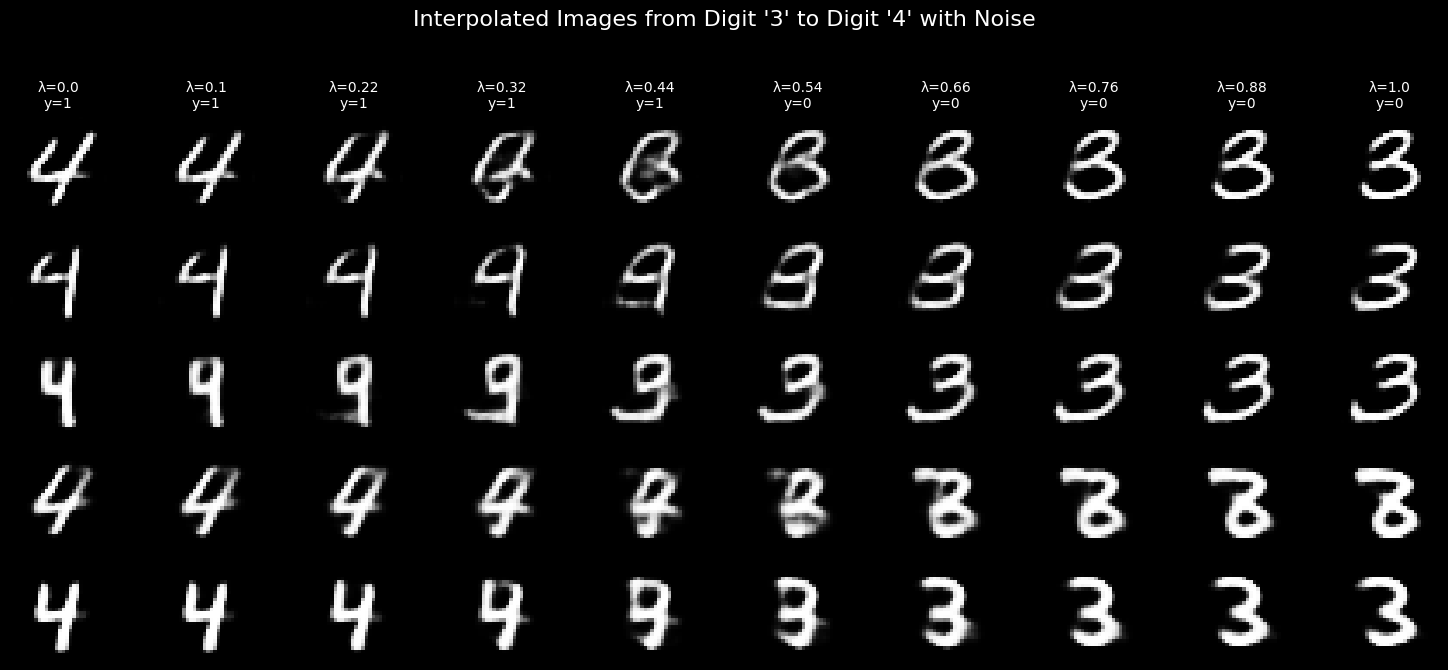

In [34]:
# Function to interpolate between pairs of images in two batches and optionally add noise
def generate_interpolated_images_batch(model, img_batch1, img_batch2, num_levels=10, num_samples=1, latent_noise_level=0.0):
    all_interpolated_images = []
    model.eval()
    with torch.no_grad():
        # Move image batches to the device
        img_batch1 = img_batch1.to(device)
        img_batch2 = img_batch2.to(device)
        assert img_batch1.size(0) == img_batch2.size(0), "Input batches must have the same number of images"
        batch_size = img_batch1.size(0)
        
        # Generate a shared non-informative context
        non_informative_context = generate_context(
            batch_size,
            signal_level=None,
            noise_level=context_noise_level,
            category_id=context_id,
            context_dim=context_dim,
            device=device
        )
        
        # Get latent representations for both batches
        latent_batch1 = model.encoder(img_batch1, non_informative_context)
        latent_batch2 = model.encoder(img_batch2, non_informative_context)
        
        # Interpolation levels
        lambda_values = np.linspace(0, 1, num_levels)
        for l in lambda_values:
            level_images = []  # To store all samples for this level
            for _ in range(num_samples):
                # Interpolate in latent space
                inter_latent = l * latent_batch1 + (1 - l) * latent_batch2
                # Optionally add noise
                if latent_noise_level > 0:
                    inter_latent = inter_latent + latent_noise_level * torch.randn_like(inter_latent)
                # Decode the interpolated latent vector
                inter_image = model.decoder(inter_latent, non_informative_context).cpu()
                level_images.append(inter_image)  # shape: (batch_size, C, H, W)
            # Stack samples for this level; shape: (num_samples, batch_size, C, H, W)
            level_images = torch.stack(level_images, dim=0)
            all_interpolated_images.append(level_images)
    
    # all_interpolated_images: list of length num_levels, each of shape (num_samples, batch_size, C, H, W)
    all_interpolated_images = torch.stack(all_interpolated_images, dim=0)  # shape: (num_levels, num_samples, batch_size, C, H, W)
    # Reshape to (num_levels, batch_size * num_samples, C, H, W)
    return all_interpolated_images.view(num_levels, batch_size * num_samples, *img_batch1.shape[1:])


# Function to collect a given number of examples and labels for a specific digit from the test set
def collect_digit_examples(dataloader, digit, num_examples=128):
    collected_images = []
    collected_labels = []
    for img_batch, label_batch in dataloader:
        for i in range(img_batch.size(0)):
            if label_batch[i] == digit:
                collected_images.append(img_batch[i:i+1])
                collected_labels.append(label_batch[i:i+1])
                if len(collected_images) >= num_examples:
                    return torch.cat(collected_images, dim=0), torch.cat(collected_labels, dim=0)
    if len(collected_images) > 0:
        return torch.cat(collected_images, dim=0), torch.cat(collected_labels, dim=0)
    else:
        raise ValueError(f"Not enough examples of digit {digit} found in the dataset.")


# Set the number of examples to collect for discrimination
discrimination_batch_size = 128

# Collect examples and labels of digit '3'
img_batch_3, label_batch_3 = collect_digit_examples(test_dataloader, digit=3, num_examples=discrimination_batch_size)
label_batch_3[:] = 0  # recast labels to '0' for digit '3'

# Collect examples and labels of digit '4'
img_batch_4, label_batch_4 = collect_digit_examples(test_dataloader, digit=4, num_examples=discrimination_batch_size)
label_batch_4[:] = 1  # recast labels to '1' for digit '4'

# Print to confirm sizes and label values
print(f"Collected batch size for digit '3': {img_batch_3.size()}, Labels size: {label_batch_3.size()}, Labels: {label_batch_3.unique()}")
print(f"Collected batch size for digit '4': {img_batch_4.size()}, Labels size: {label_batch_4.size()}, Labels: {label_batch_4.unique()}")

# Generate interpolated images between the two batches
num_levels = 51
num_samples = 5
interpolated_images = generate_interpolated_images_batch(
    baseline_autoencoder,
    img_batch_3,
    img_batch_4,
    num_levels=num_levels,
    num_samples=num_samples,
    latent_noise_level=0.1
)
# Expected shape: (12, 128 * 5 = 640, 1, 28, 28)

# Generate corresponding binary labels for the interpolated images.
# For each interpolation level, if λ <= 0.5 then label 1 (digit '4'), else 0 (digit '3').
interpolated_labels = []
for l in np.linspace(0, 1, num_levels):
    if l <= 0.5:
        labels = torch.ones(discrimination_batch_size, device=device)  # shape: (128,)
    else:
        labels = torch.zeros(discrimination_batch_size, device=device)  # shape: (128,)
    # Repeat each label for the num_samples times
    labels = labels.repeat(num_samples)  # now shape: (128 * 5 = 640,)
    interpolated_labels.append(labels)
interpolated_labels = torch.stack(interpolated_labels)  # shape: (12, 640)

print(f"Interpolated images shape: {interpolated_images.size()}, Interpolated labels shape: {interpolated_labels.size()}")

# Plot the interpolated images
max_samples_to_display = min(5, interpolated_images.size(1))     # rows
max_levels_to_display = min(10, interpolated_images.size(0))     # columns
# Evenly sample 'max_levels_to_display' indices from [0 ... num_levels-1]
level_indices = np.linspace(0, interpolated_images.size(0) - 1, max_levels_to_display).astype(int)
fig, axs = plt.subplots(max_samples_to_display, max_levels_to_display, figsize=(15, 7))
fig.suptitle("Interpolated Images from Digit '3' to Digit '4' with Noise", fontsize=16)
for col_idx, level_idx in enumerate(level_indices):
    for row_idx in range(max_samples_to_display):
        # Select the image at the chosen interpolation level and row_idx
        image = interpolated_images[level_idx, row_idx]  # shape: (C, H, W)
        axs[row_idx, col_idx].imshow(image.squeeze(0), cmap='gray')
        axs[row_idx, col_idx].axis('off')
        # For the first row in each column, set a title showing λ and label
        if row_idx == 0:
            lambda_val = round(level_idx / (interpolated_images.size(0) - 1), 2)
            label_val = interpolated_labels[level_idx, 0].item()  # e.g. the first sample's label
            axs[row_idx, col_idx].set_title(f'λ={lambda_val}\ny={int(label_val)}', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Helper function to collect all available examples of a specific digit from the dataloader
def collect_all_digit_examples(dataloader, digit):
    collected_images = []
    collected_labels = []

    # Iterate through the dataloader to accumulate all examples of the specified digit
    for img_batch, label_batch in dataloader:
        for i in range(img_batch.size(0)):
            if label_batch[i] == digit:
                collected_images.append(img_batch[i:i+1])
                collected_labels.append(torch.tensor([digit]))

    return torch.cat(collected_images, dim=0), torch.cat(collected_labels, dim=0)

# Collect all examples for digits '3' and '4'
images_3, labels_3 = collect_all_digit_examples(test_dataloader, digit=3)
labels_3[:] = 0  # Label '0' for digit '3'

images_4, labels_4 = collect_all_digit_examples(test_dataloader, digit=4)
labels_4[:] = 1  # Label '1' for digit '4'

# Combine the data for digits '3' and '4'
all_images = torch.cat([images_3, images_4], dim=0)
all_labels = torch.cat([labels_3, labels_4], dim=0)

# Split the data into 80% train and 20% test sets
train_images, test_images, train_labels, test_labels = train_test_split(
    all_images, all_labels, test_size=0.2, stratify=all_labels, random_state=42
)

# Ensure labels are in float type
train_labels = train_labels.float().to(device)
test_labels = test_labels.float().to(device)

# Move data to the appropriate device
train_images = train_images.to(device)
test_images = test_images.to(device)

print(f"Training set size: {train_images.size(0)} images")
print(f"Testing set size: {test_images.size(0)} images")

# Define the discriminator model
class Discriminator(nn.Module):
    def __init__(self, encoder, latent_dim):
        super(Discriminator, self).__init__()
        self.encoder = encoder
        self.logistic = nn.Linear(latent_dim, 1)

    def forward(self, x, context):
        with torch.no_grad():
            latent_repr = self.encoder(x, context)
        latent_repr = latent_repr.view(latent_repr.size(0), -1)
        output = self.logistic(latent_repr)
        return output
    
# Function to evaluate the discriminator model
def evaluate_discriminator(model, images, labels, context):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        # Get the outputs from the model
        outputs = model(images, context).squeeze()
        # Apply sigmoid to convert logits to probabilities
        predictions = torch.sigmoid(outputs) > 0.5  # Threshold at 0.5 for binary classification
        # Calculate accuracy
        accuracy = accuracy_score(labels.cpu().numpy(), predictions.cpu().numpy())
    return accuracy

# Ensure correct latent dimension
sample_image = train_images[0:1].to(device)
sample_context = generate_context(1, signal_level=None, noise_level=context_noise_level, category_id=context_id, context_dim=10, device=device)
latent_dim = association_autoencoder.encoder(sample_image, sample_context).view(sample_image.size(0), -1).size(1)

# Initialize the discriminator
discriminator = Discriminator(association_autoencoder.encoder, latent_dim).to(device)

# Train the discriminator
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(discriminator.logistic.parameters(), lr=0.001)
num_epochs = 200

for epoch in range(num_epochs):
    discriminator.train()
    optimizer.zero_grad()
    context_train = generate_context(train_images.size(0), signal_level=None, noise_level=context_noise_level, category_id=context_id, context_dim=10, device=device)
    outputs = discriminator(train_images, context_train).squeeze()
    loss = criterion(outputs, train_labels)
    loss.backward()
    optimizer.step()
    # print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

# Evaluate on training data
train_accuracy = evaluate_discriminator(discriminator, train_images, train_labels, context_train)
print(f"Training Accuracy: {train_accuracy:.4f}")

# Evaluate on the test data
context_test = generate_context(test_images.size(0), signal_level=None, noise_level=context_noise_level, category_id=context_id, context_dim=10, device=device)
test_accuracy = evaluate_discriminator(discriminator, test_images, test_labels, context_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Generate contexts for evaluation
num_samples_per_level = interpolated_images.size(1)  # Total number of samples per interpolation level
context_associated = generate_context(num_samples_per_level, signal_level=test_context_signal_level, noise_level=context_noise_level, category_id=context_id, context_dim=10, device=device)
context_no_context = generate_context(num_samples_per_level, signal_level=None, noise_level=context_noise_level, category_id=context_id, context_dim=10, device=device)

# Initialize lists to hold prediction accuracies
predictions_with_context = []
predictions_no_context = []

# Loop through each interpolation level and evaluate the model
for i in range(num_levels):

    # get the interpolated images and labels
    batch_interpolated = interpolated_images[i].to(device)
    label_interpolated = interpolated_labels[i].to(device)

    # Debug, print shapes of the batch and labels and context
    print(f"Batch shape: {batch_interpolated.size()}, Label shape: {label_interpolated.size()}, Context shape: {context_associated.size()}")
                                                                    
    # Evaluate with context
    acc_with_context = evaluate_discriminator(discriminator, batch_interpolated, label_interpolated, context_associated)
    predictions_with_context.append(acc_with_context)

    # Evaluate without context
    acc_no_context = evaluate_discriminator(discriminator, batch_interpolated, label_interpolated, context_no_context)
    predictions_no_context.append(acc_no_context)

Training set size: 1593 images
Testing set size: 399 images
Training Accuracy: 0.9611
Test Accuracy: 0.9674
Batch shape: torch.Size([640, 1, 28, 28]), Label shape: torch.Size([640]), Context shape: torch.Size([640, 10])
Batch shape: torch.Size([640, 1, 28, 28]), Label shape: torch.Size([640]), Context shape: torch.Size([640, 10])
Batch shape: torch.Size([640, 1, 28, 28]), Label shape: torch.Size([640]), Context shape: torch.Size([640, 10])
Batch shape: torch.Size([640, 1, 28, 28]), Label shape: torch.Size([640]), Context shape: torch.Size([640, 10])
Batch shape: torch.Size([640, 1, 28, 28]), Label shape: torch.Size([640]), Context shape: torch.Size([640, 10])
Batch shape: torch.Size([640, 1, 28, 28]), Label shape: torch.Size([640]), Context shape: torch.Size([640, 10])
Batch shape: torch.Size([640, 1, 28, 28]), Label shape: torch.Size([640]), Context shape: torch.Size([640, 10])
Batch shape: torch.Size([640, 1, 28, 28]), Label shape: torch.Size([640]), Context shape: torch.Size([640, 1

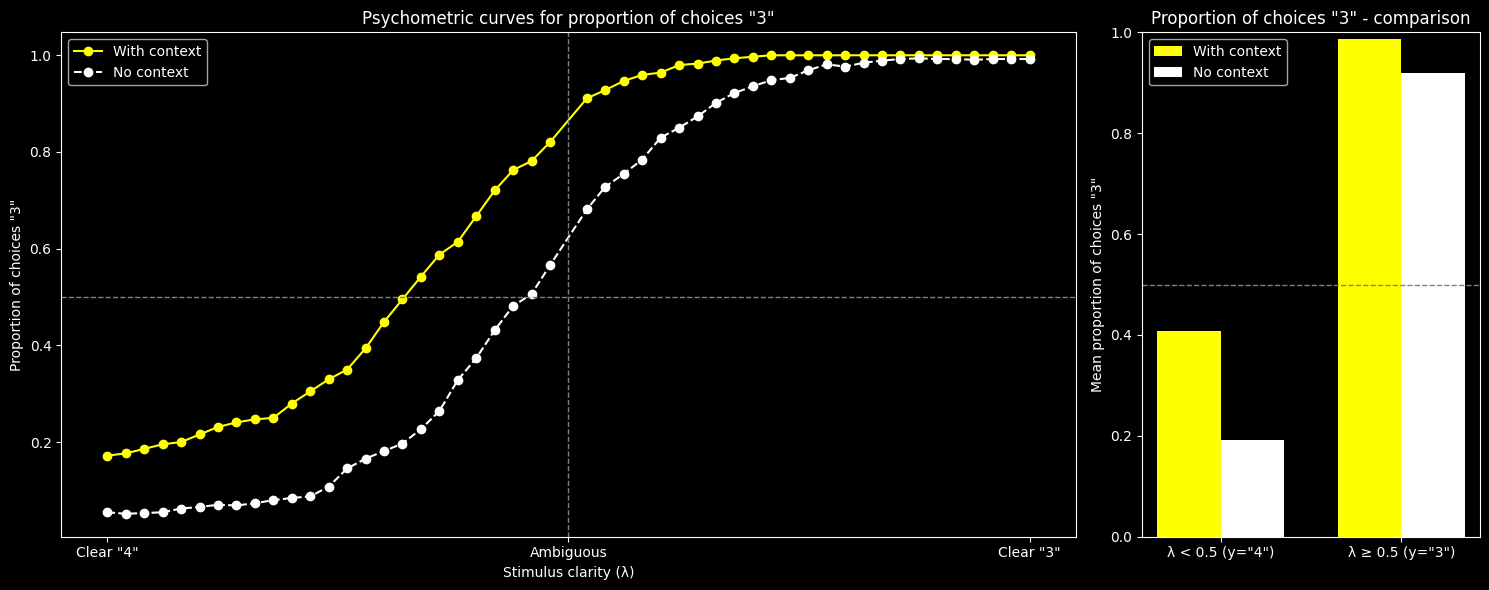

In [36]:
# Convert predictions to NumPy arrays
predictions_with_context = np.array(predictions_with_context)
predictions_no_context = np.array(predictions_no_context)

# Calculate the proportion of "3" choices based on classifier performance
proportions_with_context = np.concatenate([(1 - predictions_with_context[:num_levels // 2]), 
                                           predictions_with_context[num_levels // 2:]])
proportions_no_context = np.concatenate([(1 - predictions_no_context[:num_levels // 2]), 
                                         predictions_no_context[num_levels // 2:]])

# Exclude the ambiguous point (middle point)
exclude_index = num_levels // 2
x_values = np.linspace(0, 1, num_levels)
x_values = np.delete(x_values, exclude_index)
proportions_with_context = np.delete(proportions_with_context, exclude_index)
proportions_no_context = np.delete(proportions_no_context, exclude_index)

# Split the data into left (λ < 0.5) and right (λ ≥ 0.5) halves for bar plots
left_half_size = num_levels // 2
right_half_size = num_levels - left_half_size  # Remaining part for the right half

# Calculate mean proportion of "3" choices for left and right halves
left_proportion_with_context = np.mean(proportions_with_context[:left_half_size])
right_proportion_with_context = np.mean(proportions_with_context[left_half_size:])
left_proportion_no_context = np.mean(proportions_no_context[:left_half_size])
right_proportion_no_context = np.mean(proportions_no_context[left_half_size:])

# Create subplots for the psychometric curves and bar plots
fig, axs = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [3, 1]})

# Psychometric curves plot for proportion of choices "3"
axs[0].plot(x_values, proportions_with_context, label='With context', color='yellow', marker='o', linestyle='-')
axs[0].plot(x_values, proportions_no_context, label='No context', color='white', marker='o', linestyle='--')
axs[0].axhline(0.5, color='gray', linestyle='--', linewidth=1)  # Dashed line for 50% proportion
axs[0].axvline(0.5, color='gray', linestyle='--', linewidth=1)  # Vertical line at the center

# Labeling and formatting
axs[0].set_xticks([0, 0.5, 1])
axs[0].set_xticklabels(['Clear "4"', "Ambiguous", 'Clear "3"'])
axs[0].set_xlabel('Stimulus clarity (λ)')
axs[0].set_ylabel('Proportion of choices "3"')
axs[0].set_title('Psychometric curves for proportion of choices "3"')
axs[0].legend()

# Bar plot for left and right proportion comparison
bar_width = 0.35
bar_labels = ['λ < 0.5 (y="4")', 'λ ≥ 0.5 (y="3")']
axs[1].bar([0, 1], [left_proportion_with_context, right_proportion_with_context], bar_width, label='With context', color='yellow')
axs[1].bar([0 + bar_width, 1 + bar_width], [left_proportion_no_context, right_proportion_no_context], bar_width, label='No context', color='white')

# Formatting the bar plot
axs[1].set_xticks([0 + bar_width / 2, 1 + bar_width / 2])
axs[1].set_xticklabels(bar_labels)
axs[1].set_ylim(0, 1)
axs[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axs[1].set_ylabel('Mean proportion of choices "3"')
axs[1].set_title('Proportion of choices "3" - comparison')
axs[1].legend()
plt.tight_layout()
plt.show()